# 10 · Output head + the training objective

Two final pieces turn the stack of blocks into a trainable language model:

- **Output head:** a `Linear` maps each token's final vector to one **logit** (raw score) per
  vocabulary word. `softmax` turns logits into next-token probabilities.
- **Objective — next-token prediction:** compare the predicted distribution to the *true* next
  token using **cross-entropy loss**, then backpropagate. No human labels needed — the text
  itself is the supervision. This self-supervised pretraining is what produces a **Base**
  model.

In [1]:
import numpy as np
np.random.seed(0)
def softmax(x): x = x - x.max(); e = np.exp(x); return e / e.sum()

D_MODEL, VOCAB = 32, 12
token_vector = np.random.randn(D_MODEL)      # a token's final vector out of the stack
head = np.random.randn(D_MODEL, VOCAB)       # output projection: d_model -> vocab

logits = token_vector @ head                 # one raw score per vocab word
probs  = softmax(logits)
pred   = probs.argmax()
print("predicted next token id:", pred, "with prob", round(float(probs[pred]), 3))

true_id = 7                                   # suppose the real next token is id 7
loss = -np.log(probs[true_id])                # cross-entropy = -log(prob of the correct token)
print("cross-entropy loss for true id 7:", round(float(loss), 3))
print("training nudges the weights to raise probs[7] -> loss shrinks toward 0")

predicted next token id: 4 with prob 0.98
cross-entropy loss for true id 7: 22.093
training nudges the weights to raise probs[7] -> loss shrinks toward 0


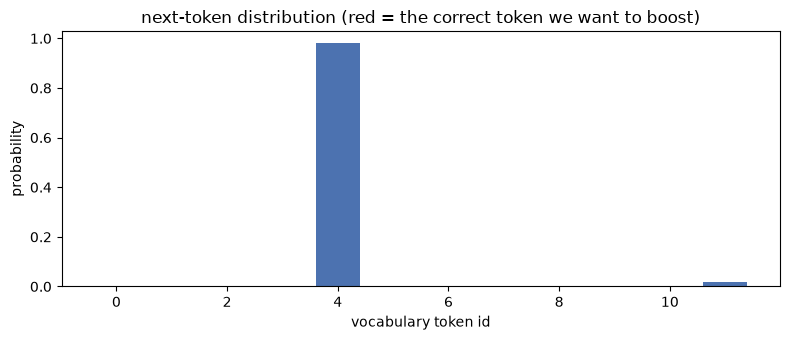

In [2]:
# Visual: the predicted distribution over the vocabulary, true token highlighted.
import matplotlib.pyplot as plt
colors = ["#C44E52" if i == true_id else "#4C72B0" for i in range(VOCAB)]
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(range(VOCAB), probs, color=colors)
ax.set_xlabel("vocabulary token id"); ax.set_ylabel("probability")
ax.set_title("next-token distribution (red = the correct token we want to boost)")
plt.tight_layout(); plt.show()

**Takeaway.** Head → logits → softmax → probabilities; cross-entropy against the true next
token drives learning. Run this over trillions of tokens and you get a **Base** model.

That completes the mechanism. Next: **11 · architecture families & modern tricks** — how real
LLMs vary this recipe, and how it connects back to Base / Instruct / Reasoning.